# Telco Customer Churn Prediction

Predicting customer churn for a telecom company using the IBM Telco Customer Churn dataset.
The notebook covers exploratory data analysis, feature engineering, data cleaning, and
training/comparing 10 classification models with SMOTE for class imbalance, followed by
hyperparameter tuning on the best-performing model.

**Dataset:** `Telo_Customer_Churn.csv` — 7,043 customers, 21 features (demographics, account
info, subscribed services) with a binary `Churn` target.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Telco_Customer_Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df[df.duplicated()].shape[0]

0

## Exploratory Data Analysis
Visualizing churn distribution across categorical features, tenure vs. contract type,
and monthly charges vs. internet service.

In [7]:
import math

def plot_all_count(df, columns_to_plot,title_prefix = ""):
    n_cols = 3
    n_rows = math.ceil(len(columns_to_plot) / n_cols )

    plt.figure(figsize =(5 * n_cols, 4 * n_rows))

    for i ,col in enumerate(columns_to_plot,1):
        plt.subplot(n_rows, n_cols, i)
        sns.countplot(data = df,x= col,hue = "Churn")
        plt.title(f"{title_prefix} {col}")
        plt.xlabel("")
        plt.ylabel("")

        plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

In [8]:
select_data = ["Contract","InternetService","PaymentMethod","OnlineBackup","gender","SeniorCitizen","Partner","Dependents"]

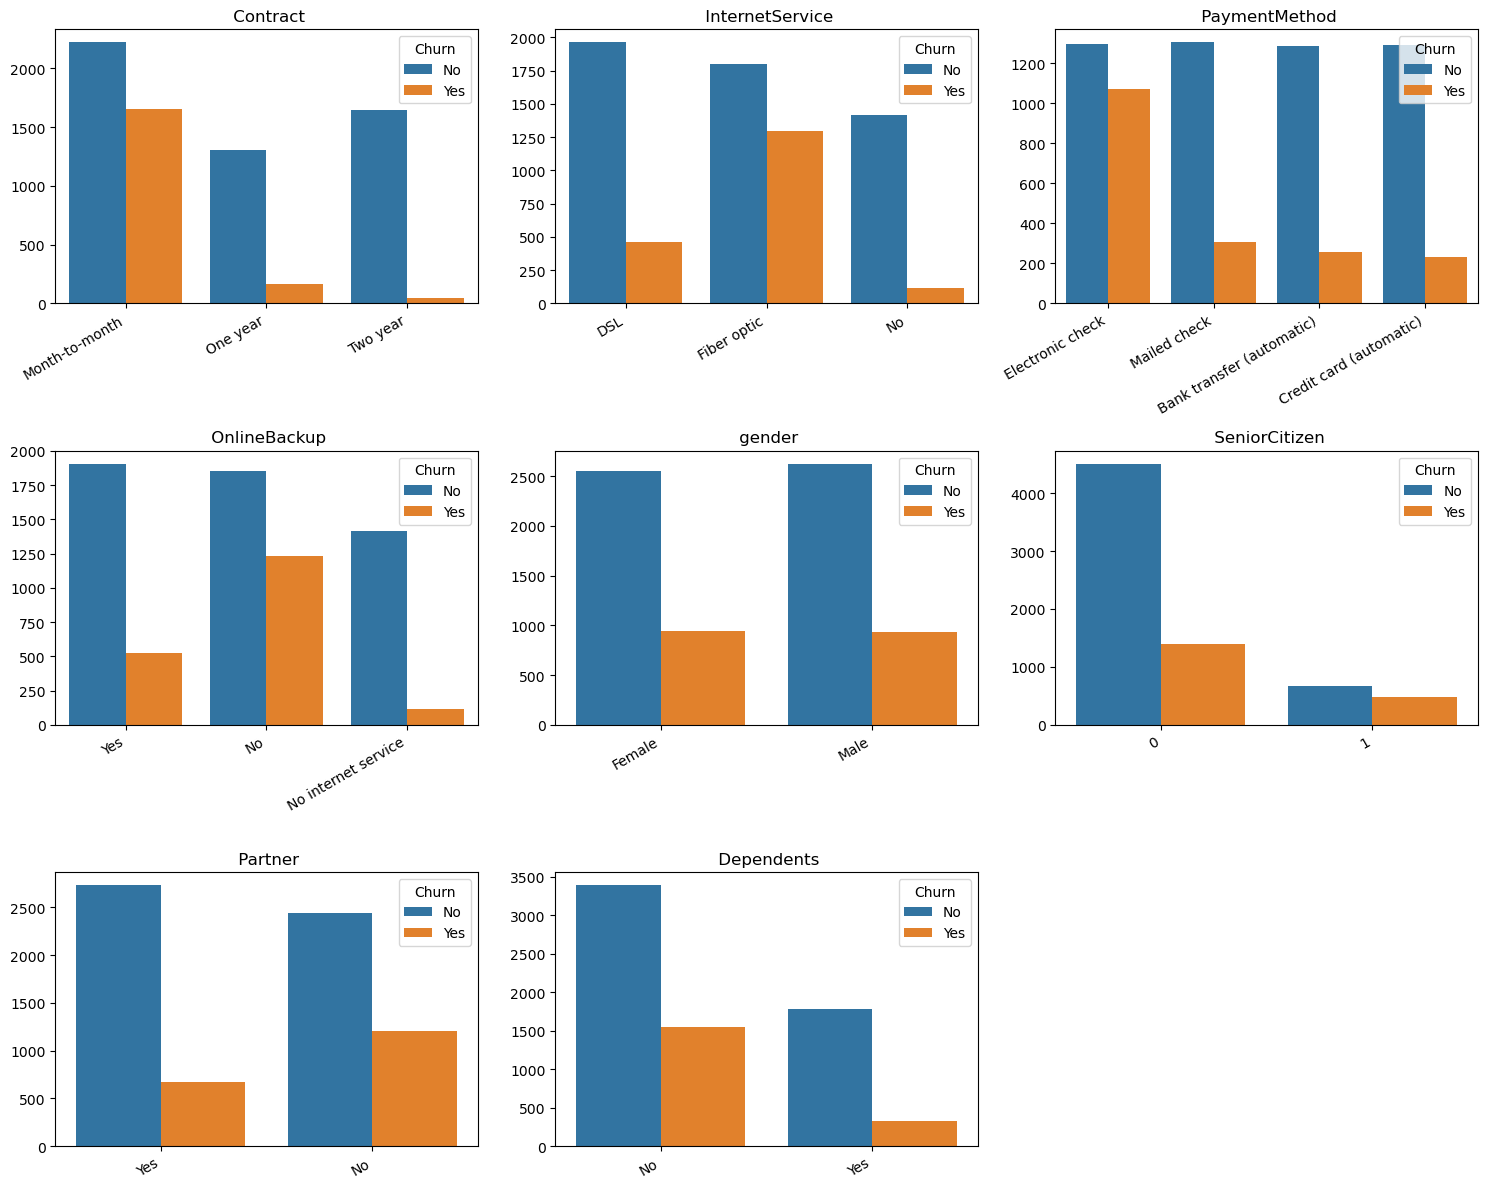

In [9]:
plot_all_count(df,select_data)

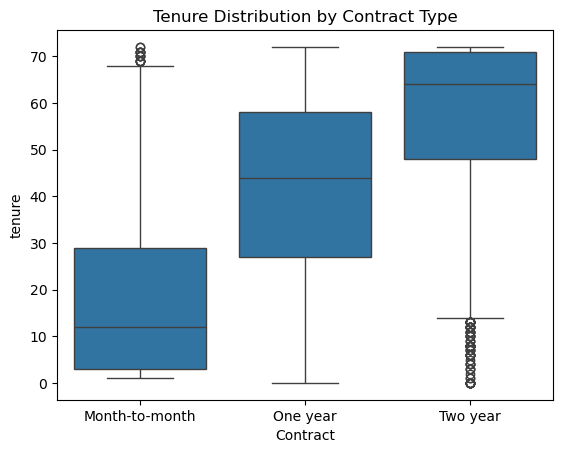

In [10]:
sns.boxplot(data = df, x = "Contract", y = "tenure")
plt.title("Tenure Distribution by Contract Type")
plt.show()

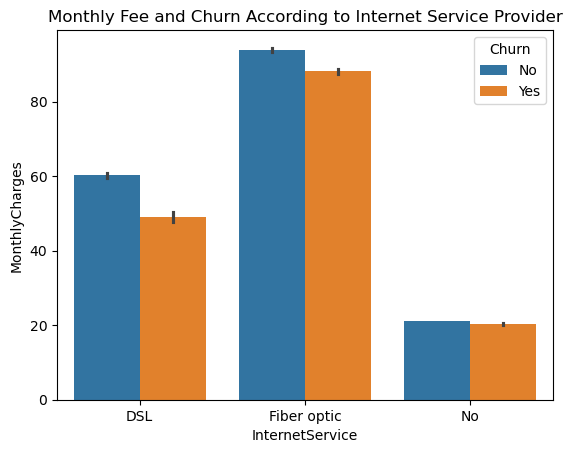

In [11]:
sns.barplot(data = df, x = "InternetService", y = "MonthlyCharges", hue = "Churn")
plt.title("Monthly Fee and Churn According to Internet Service Provider")
plt.show()

In [12]:
df[df["tenure"] == 0]["Churn"]

488     No
753     No
936     No
1082    No
1340    No
3331    No
3826    No
4380    No
5218    No
6670    No
6754    No
Name: Churn, dtype: object

In [13]:
df[df["tenure"] == 0].shape[0]

11

In [14]:
df[(df["PhoneService"]=="No") & (df["MultipleLines"]!="No phone service")]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [16]:
df["tenure"].unique()

array([ 1, 34,  2, 45,  8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71,
       21, 12, 30, 47, 72, 17, 27,  5, 46, 11, 70, 63, 43, 15, 60, 18, 66,
        9,  3, 31, 50, 64, 56,  7, 42, 35, 48, 29, 65, 38, 68, 32, 55, 37,
       36, 41,  6,  4, 33, 67, 23, 57, 61, 14, 20, 53, 40, 59, 24, 44, 19,
       54, 51, 26,  0, 39])

In [17]:
df["tenure_group"] = pd.cut(df["tenure"], bins=[0, 12, 24, 48, 72], labels=["New", "1-2 Year", "2-4 Year", "4+ Year"],include_lowest=True)

In [18]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,New
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.5,No,2-4 Year
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,New
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,2-4 Year
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,New


In [19]:
df["tenure_group"].value_counts()

tenure_group
4+ Year     2239
New         2186
2-4 Year    1594
1-2 Year    1024
Name: count, dtype: int64

In [20]:
tenure_group_by =df.groupby("tenure_group")

In [21]:
tenure_group_by["Churn"].value_counts(normalize = True)

tenure_group  Churn
New           No       0.525618
              Yes      0.474382
1-2 Year      No       0.712891
              Yes      0.287109
2-4 Year      No       0.796110
              Yes      0.203890
4+ Year       No       0.904868
              Yes      0.095132
Name: proportion, dtype: float64

In [22]:
for i in df:
    print(df[i].value_counts())

customerID
7590-VHVEG    1
3791-LGQCY    1
6008-NAIXK    1
5956-YHHRX    1
5365-LLFYV    1
             ..
9796-MVYXX    1
2637-FKFSY    1
1552-AAGRX    1
4304-TSPVK    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64
gender
Male      3555
Female    3488
Name: count, dtype: int64
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
OnlineSecurity
No                     3498
Yes                    2019
No internet service    15

## Feature Engineering
Creating derived features:
- `tenure_group`: bucketed tenure (used for EDA only, dropped before modeling)
- `total_services`: count of subscribed add-on services
- `is_automatic_payment`: whether the customer uses automatic payment

In [23]:
service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

In [24]:
(df[service_cols] =="Yes").sum(axis = 1)

0       1
1       2
2       2
3       3
4       0
       ..
7038    5
7039    4
7040    1
7041    0
7042    5
Length: 7043, dtype: int64

In [25]:
df["total_services"] = (df[service_cols] == "Yes").sum(axis=1)

In [26]:
total_service_group = df.groupby("total_services")
total_service_group["Churn"].value_counts(normalize=True)

total_services  Churn
0               No       0.785940
                Yes      0.214060
1               No       0.542443
                Yes      0.457557
2               No       0.641820
                Yes      0.358180
3               No       0.726297
                Yes      0.273703
4               No       0.776995
                Yes      0.223005
5               No       0.875657
                Yes      0.124343
6               No       0.947183
                Yes      0.052817
Name: proportion, dtype: float64

In [27]:
df[df["total_services"] == 0].groupby("InternetService")["Churn"].value_counts(normalize = True)

InternetService  Churn
DSL              No       0.588435
                 Yes      0.411565
Fiber optic      Yes      0.604010
                 No       0.395990
No               No       0.925950
                 Yes      0.074050
Name: proportion, dtype: float64

In [28]:
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [29]:
df[df["PaymentMethod"].str.contains("automatic")]["Churn"].value_counts(normalize = True)

Churn
No     0.840183
Yes    0.159817
Name: proportion, dtype: float64

In [30]:
df[~df["PaymentMethod"].str.contains("automatic")]["Churn"].value_counts(normalize = True)

Churn
No     0.653256
Yes    0.346744
Name: proportion, dtype: float64

In [31]:
df["is_automatic_payment"] = df["PaymentMethod"].str.contains("automatic")

## Data Cleaning & Encoding
Converting categorical Yes/No fields to binary, fixing `TotalCharges` (stored as string with
blank values for customers with 0 tenure), consolidating "No internet/phone service" values
into "No", and ordinal-encoding `Contract`.

In [32]:
binary_value = ["Partner","Dependents","PhoneService","PaperlessBilling","Churn"]

In [33]:
for i in binary_value:
    df[i] = df[i].map({"Yes": 1, "No": 0})

In [34]:
df["gender"] = df["gender"].map({"Female" :1,  "Male":0})

In [35]:
#df["TotalCharges"].astype(float)

In [36]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan).astype(float)
print("Number of missing values:", df["TotalCharges"].isnull().sum())
df["TotalCharges"] = df["TotalCharges"].fillna(0)

Number of missing values: 11


In [37]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,total_services,is_automatic_payment
7038,6840-RESVB,0,0,1,1,24,1,Yes,DSL,Yes,...,Yes,One year,1,Mailed check,84.80,1990.50,0,1-2 Year,5,False
7039,2234-XADUH,1,0,1,1,72,1,Yes,Fiber optic,No,...,Yes,One year,1,Credit card (automatic),103.20,7362.90,0,4+ Year,4,True
7040,4801-JZAZL,1,0,1,1,11,0,No phone service,DSL,Yes,...,No,Month-to-month,1,Electronic check,29.60,346.45,0,New,1,False
7041,8361-LTMKD,0,1,1,0,4,1,Yes,Fiber optic,No,...,No,Month-to-month,1,Mailed check,74.40,306.60,1,New,0,False
7042,3186-AJIEK,0,0,0,0,66,1,No,Fiber optic,Yes,...,Yes,Two year,1,Bank transfer (automatic),105.65,6844.50,0,4+ Year,5,True


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   customerID            7043 non-null   object  
 1   gender                7043 non-null   int64   
 2   SeniorCitizen         7043 non-null   int64   
 3   Partner               7043 non-null   int64   
 4   Dependents            7043 non-null   int64   
 5   tenure                7043 non-null   int64   
 6   PhoneService          7043 non-null   int64   
 7   MultipleLines         7043 non-null   object  
 8   InternetService       7043 non-null   object  
 9   OnlineSecurity        7043 non-null   object  
 10  OnlineBackup          7043 non-null   object  
 11  DeviceProtection      7043 non-null   object  
 12  TechSupport           7043 non-null   object  
 13  StreamingTV           7043 non-null   object  
 14  StreamingMovies       7043 non-null   object  
 15  Cont

In [39]:
df.select_dtypes("O")

,customerID,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaymentMethod
0,7590-VHVEG,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Electronic check
1,5575-GNVDE,No,DSL,Yes,No,Yes,No,No,No,One year,Mailed check
2,3668-QPYBK,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Mailed check
3,7795-CFOCW,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,Bank transfer (automatic)
4,9237-HQITU,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Electronic check
...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Mailed check
7039,2234-XADUH,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Credit card (automatic)
7040,4801-JZAZL,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Electronic check
7041,8361-LTMKD,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Mailed check


In [40]:
change_col = ["OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]

In [41]:
for i in change_col:
    print(df[i].value_counts())

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64
StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64
StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64


In [42]:
for i in change_col:
    df[i] = df[i].replace("No internet service","No")

In [43]:
for i in change_col:
    print(df[i].value_counts())

OnlineSecurity
No     5024
Yes    2019
Name: count, dtype: int64
OnlineBackup
No     4614
Yes    2429
Name: count, dtype: int64
DeviceProtection
No     4621
Yes    2422
Name: count, dtype: int64
TechSupport
No     4999
Yes    2044
Name: count, dtype: int64
StreamingTV
No     4336
Yes    2707
Name: count, dtype: int64
StreamingMovies
No     4311
Yes    2732
Name: count, dtype: int64


In [44]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,total_services,is_automatic_payment
0,7590-VHVEG,1,0,1,0,1,0,No phone service,DSL,No,...,No,Month-to-month,1,Electronic check,29.85,29.85,0,New,1,False
1,5575-GNVDE,0,0,0,0,34,1,No,DSL,Yes,...,No,One year,0,Mailed check,56.95,1889.50,0,2-4 Year,2,False
2,3668-QPYBK,0,0,0,0,2,1,No,DSL,Yes,...,No,Month-to-month,1,Mailed check,53.85,108.15,1,New,2,False
3,7795-CFOCW,0,0,0,0,45,0,No phone service,DSL,Yes,...,No,One year,0,Bank transfer (automatic),42.30,1840.75,0,2-4 Year,3,True
4,9237-HQITU,1,0,0,0,2,1,No,Fiber optic,No,...,No,Month-to-month,1,Electronic check,70.70,151.65,1,New,0,False


In [45]:
for i in change_col:
    df[i] = df[i].map({"Yes": 1, "No": 0})

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   customerID            7043 non-null   object  
 1   gender                7043 non-null   int64   
 2   SeniorCitizen         7043 non-null   int64   
 3   Partner               7043 non-null   int64   
 4   Dependents            7043 non-null   int64   
 5   tenure                7043 non-null   int64   
 6   PhoneService          7043 non-null   int64   
 7   MultipleLines         7043 non-null   object  
 8   InternetService       7043 non-null   object  
 9   OnlineSecurity        7043 non-null   int64   
 10  OnlineBackup          7043 non-null   int64   
 11  DeviceProtection      7043 non-null   int64   
 12  TechSupport           7043 non-null   int64   
 13  StreamingTV           7043 non-null   int64   
 14  StreamingMovies       7043 non-null   int64   
 15  Cont

In [47]:
df.drop("customerID",axis = 1 , inplace = True)

In [48]:
df["MultipleLines"].unique()

array(['No phone service', 'No', 'Yes'], dtype=object)

In [49]:
df["MultipleLines"] = df["MultipleLines"].replace("No phone service","No")
df["MultipleLines"] = df["MultipleLines"].map({"No" : 0 ,"Yes": 1})

In [50]:
df.isnull().sum()

gender                  0
SeniorCitizen           0
Partner                 0
Dependents              0
tenure                  0
PhoneService            0
MultipleLines           0
InternetService         0
OnlineSecurity          0
OnlineBackup            0
DeviceProtection        0
TechSupport             0
StreamingTV             0
StreamingMovies         0
Contract                0
PaperlessBilling        0
PaymentMethod           0
MonthlyCharges          0
TotalCharges            0
Churn                   0
tenure_group            0
total_services          0
is_automatic_payment    0
dtype: int64

In [51]:
df["is_automatic_payment"] = df["is_automatic_payment"].astype(int)

In [52]:
df.drop("tenure_group",axis = 1 , inplace = True)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   gender                7043 non-null   int64  
 1   SeniorCitizen         7043 non-null   int64  
 2   Partner               7043 non-null   int64  
 3   Dependents            7043 non-null   int64  
 4   tenure                7043 non-null   int64  
 5   PhoneService          7043 non-null   int64  
 6   MultipleLines         7043 non-null   int64  
 7   InternetService       7043 non-null   object 
 8   OnlineSecurity        7043 non-null   int64  
 9   OnlineBackup          7043 non-null   int64  
 10  DeviceProtection      7043 non-null   int64  
 11  TechSupport           7043 non-null   int64  
 12  StreamingTV           7043 non-null   int64  
 13  StreamingMovies       7043 non-null   int64  
 14  Contract              7043 non-null   object 
 15  PaperlessBilling     

In [54]:
print(df["InternetService"].value_counts())
print(df["Contract"].value_counts())
df["PaymentMethod"].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [55]:
df["Contract"] = df["Contract"].map({"Month-to-month":0,"One year":1,"Two year":2})

## Train-Test Split
70/30 stratified split, done before any fitting-based preprocessing to avoid data leakage.

In [56]:
X = df.drop("Churn",axis = 1)
y = df["Churn"]

In [57]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=45,stratify=y)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print(y_train.value_counts(normalize=True))

Train: (4930, 21) | Test: (2113, 21)
Churn
0    0.734686
1    0.265314
Name: proportion, dtype: float64


## Preprocessing Pipeline
One-hot encoding for nominal categoricals (`InternetService`, `PaymentMethod`) and standard
scaling for numeric features, combined in a `ColumnTransformer`.

In [58]:
one_hot_categories = ["InternetService","PaymentMethod"]

In [59]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [60]:
one_hot_categories = ["InternetService", "PaymentMethod"]
numeric_cols = [c for c in X.columns if c not in one_hot_categories]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), one_hot_categories),
        ("num", StandardScaler(), numeric_cols),
    ]
)

## Model Comparison
Training 10 classifiers, each wrapped in the same `imblearn.Pipeline`
(preprocessing → SMOTE → model), so every model is evaluated under identical conditions and
SMOTE is applied only to training data — no leakage into the test set.

In [61]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
import lightgbm as lgb

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)

USE_SMOTE = True

model_defs = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVC": SVC(probability=True, random_state=42),
    "Gaussian NB": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),
    "LightGBM": lgb.LGBMClassifier(verbosity=-1, random_state=42),
}

fitted_pipelines = {}
results = []

for name, estimator in model_defs.items():
    steps = [("prep", preprocessor)]
    if USE_SMOTE:
        steps.append(("smote", SMOTE(random_state=42)))
    steps.append(("model", estimator))
    pipe = ImbPipeline(steps)

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    fitted_pipelines[name] = pipe
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Churn)": precision_score(y_test, y_pred, pos_label=1),
        "Recall (Churn)": recall_score(y_test, y_pred, pos_label=1),
        "F1-Score (Churn)": f1_score(y_test, y_pred, pos_label=1),
    })

results_df = pd.DataFrame(results).sort_values("F1-Score (Churn)", ascending=False).reset_index(drop=True)
results_df.round(3)

,Model,Accuracy,Precision (Churn),Recall (Churn),F1-Score (Churn)
0,AdaBoost,0.748,0.517,0.766,0.617
1,Logistic Regression,0.738,0.505,0.791,0.616
2,Gradient Boosting,0.770,0.555,0.684,0.613
3,Gaussian NB,0.735,0.500,0.747,0.599
4,SVC,0.747,0.518,0.704,0.597
5,LightGBM,0.780,0.586,0.581,0.584
6,XGBoost,0.774,0.579,0.549,0.564
7,Random Forest,0.773,0.576,0.551,0.563
8,KNN,0.693,0.451,0.715,0.553
9,Decision Tree,0.714,0.465,0.512,0.487


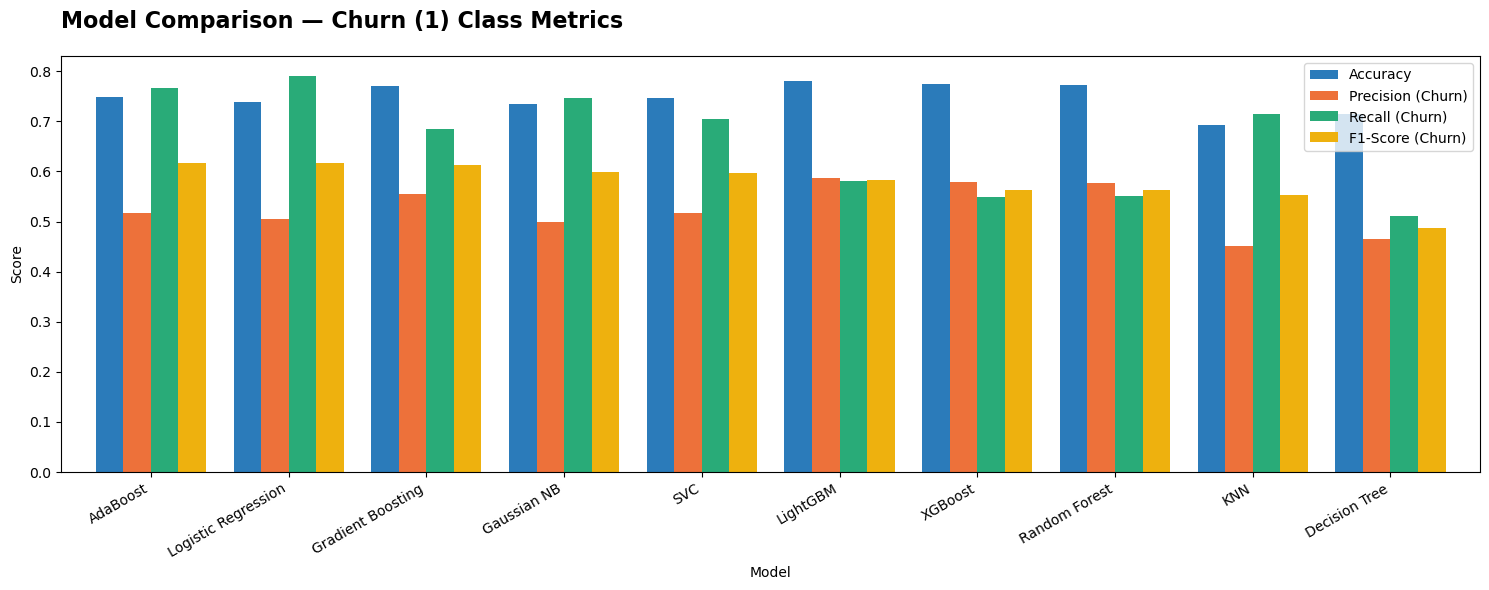

In [62]:
plot_df = results_df.set_index("Model")
colors = ['#2b7bba', '#ed713a', '#29ab78', '#eeb10e']

ax = plot_df.plot(kind='bar', figsize=(15, 6), width=0.8, color=colors)
plt.title("Model Comparison — Churn (1) Class Metrics", fontsize=16, fontweight='bold', loc='left', pad=20)
plt.ylabel("Score")
plt.xticks(rotation=30, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Hyperparameter Tuning
Tuning the best-performing model (AdaBoost) with `RandomizedSearchCV`. SMOTE stays inside the
pipeline, so it's re-applied fresh within each cross-validation fold's training split.

In [63]:
best_model_name = results_df.iloc[0]["Model"]
print("Model to be tuned:", best_model_name)

Model to be tuned: AdaBoost


In [64]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    "model__n_estimators": [50, 100, 200, 300, 500],
    "model__learning_rate": [0.001, 0.01, 0.05, 0.1, 0.5, 1.0],
}

adaboost_pipeline = fitted_pipelines[best_model_name]

random_search_ada = RandomizedSearchCV(
    estimator=adaboost_pipeline,
    param_distributions=params,
    n_iter=20,
    n_jobs=-1,
    cv=5,
    random_state=45,
    scoring="f1",
    verbose=0,
)

random_search_ada.fit(X_train, y_train)
print("Best params:", random_search_ada.best_params_)

Best params: {'model__n_estimators': 500, 'model__learning_rate': 0.5}


Accuracy: 0.7420728821580691

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.74      0.81      1552
           1       0.51      0.75      0.61       561

    accuracy                           0.74      2113
   macro avg       0.70      0.74      0.71      2113
weighted avg       0.79      0.74      0.75      2113



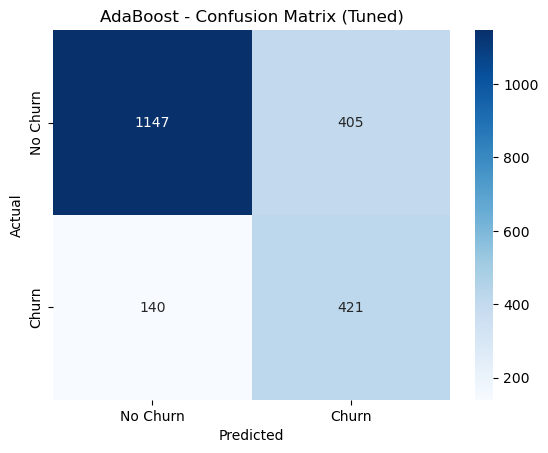

In [65]:
final_model = random_search_ada.best_estimator_
y_pred_final = final_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("\nClassification Report:\n", classification_report(y_test, y_pred_final))

cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'{best_model_name} - Confusion Matrix (Tuned)')
plt.show()

## Conclusion
The tuned AdaBoost model achieves ~0.74 accuracy and 0.61 F1 on the churn class, with 0.75
recall — prioritizing catching likely-to-churn customers over precision, which fits a
retention-campaign use case. Contract type, tenure, and monthly charges are the strongest
churn signals based on the EDA.